In [ ]:
# %pip install sns

import pandas as pd
import numpy as np
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 20)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.decomposition import PCA
from scipy.stats import randint, uniform
import joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 18.6 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip3.10 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Data Preprocessing

In [3]:
df = pd.read_csv("./datasets/final.csv")
first = ["name", "nvar"]
df = df[first + [c for c in df.columns if c not in first]]
df["nvar"].value_counts
df = df.sort_values(["name", "nvar", "mem"]).reset_index()
df

,index,name,nvar,nvmops,objective,eval_duration_solver,extract_duration_solver,stats_elapsed_time,dual_feas,status,timed_bytes,timed_time,timed_gctime,nlp_warmup_time,mem,neval_grad,iter,source_solver,problem,neval_obj,timestamp_solver,error_solver,vector_type,extract_duration_problem,highest_degree (ExprTree),nln_nnzj,adbackend_hessian_backend_type,minimize,count_plus_minus,alloc_obj,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,tree_length,count_trigonometric_function,matrix_free,nlin,time_obj,tree_depth,is_constant (ExprTree),nnzj,alloc_hprod,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,count_exponential_function,islp,count_op_function,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,time_grad,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,eval_duration_problem,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,alloc_grad,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,total_alloc
0,15689,arglina,100,1.0,5.000000e+01,0.319062,0.011306,0.000135,7.841650e-15,first_order,18576.0,0.000164,0.000000,0.377710,1,4.0,1.0,OptimizationProb...,OptimizationProb...,4.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,4.261110e+07,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,77.126264
1,15690,arglina,100,1.0,5.000000e+01,0.319062,0.011309,0.000151,7.841650e-15,first_order,22120.0,0.000199,0.000000,0.377710,2,2.0,1.0,OptimizationProb...,OptimizationProb...,2.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,4.261110e+07,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,77.126264
2,15691,arglina,100,1.0,5.000000e+01,0.319062,0.011275,0.000140,7.841650e-15,first_order,25592.0,0.000182,0.000000,0.377710,3,2.0,1.0,OptimizationProb...,OptimizationProb...,2.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt

### Identity the features and targets for this model

In [4]:
feature_cols_reg = [
                    # Core Features
                    "nvar", 
                    "tree_length", 
                    "tree_depth", 
                    "time_obj",  # initial eval
                    "time_grad",
                    "mem",
                    "extract_duration_problem",
                    "eval_duration_problem",
                    
                    # Expression Tree Features
                    "highest_degree (ExprTree)",
                    "count_plus_minus",
                    "count_trigonometric_function",
                    "count_exponential_function",
                    "count_op_function",

                    # allocation
                    "alloc_obj",
                    "alloc_grad",
                    "total_alloc",
                  ]

target_cols_reg = [ "neval_obj",
                    "neval_grad",
                    "timed_bytes"] #(neval_obj, neval_grad, timed_bytes)

target_col_model = ["stats_elapsed_time"]

group_key = ["problem", "name", "nvar"]                                                                                                                   # [...]   
first = list(set(group_key + feature_cols_reg + target_cols_reg  + target_col_model))
df = df[first + [c for c in df.columns if c not in first]]    
df                                                                                       # [1, x41 x42 ... x44]

,tree_depth,neval_grad,mem,problem,neval_obj,time_grad,eval_duration_problem,count_plus_minus,timed_bytes,nvar,highest_degree (ExprTree),count_op_function,name,count_trigonometric_function,stats_elapsed_time,count_exponential_function,time_obj,tree_length,extract_duration_problem,total_alloc,alloc_grad,alloc_obj,index,nvmops,objective,eval_duration_solver,extract_duration_solver,dual_feas,status,timed_time,timed_gctime,nlp_warmup_time,iter,source_solver,timestamp_solver,error_solver,vector_type,nln_nnzj,adbackend_hessian_backend_type,minimize,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,matrix_free,nlin,is_constant (ExprTree),nnzj,alloc_hprod,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,islp,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type
0,9.0,4.0,1,OptimizationProb...,4.0,0.464686,1.980544,305.0,18576.0,100,2.0,509.0,arglina,0.0,0.000135,0.0,0.376715,10404.0,4.309682,77.126264,4.261110e+07,34515160.0,15689,1.0,5.000000e+01,0.319062,0.011306,7.841650e-15,first_order,0.000164,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN
1,9.0,2.0,2,OptimizationProb...,2.0,0.464686,1.980544,305.0,22120.0,100,2.0,509.0,arglina,0.0,0.000151,0.0,0.376715,10404.0,4.309682,77.126264,4.261110e+07,34515160.0,15690,1.0,5.000000e+01,0.319062,0.011309,7.841650e-15,first_order,0.000199,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN
2,9.0,2.0,3,OptimizationProb...,2.0,0.464686,1.980544,305.0,25592.0,100,2.0,509.0,arglina,0.0,0.000140,0.0,0.376715,10404.0,4.309682,77.126264,4.261110e+07,34515160.0,15691,1.0,5.000000e+01,0.319062,0.011275,7.841650e-15,first_order,0.000182,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,Fal

In [5]:
df = df.copy()
df["mem_count"] = df.groupby(["problem", "name", "nvar"]).transform('size')
df = df[df["mem_count"] == 100].copy().reset_index(drop=True)
df.to_csv("./datasets/final_cleaned.csv", index=False)

In [6]:
# unique instances: one row per (problem, nvar)
instances = df[group_key].drop_duplicates()

# shuffle instances
instances = instances.sample(frac=1, random_state=66).reset_index(drop=True)

n = len(instances)
n_train = int(0.8 * n)

train_inst = instances.iloc[:n_train]
test_inst  = instances.iloc[n_train :]

# assign rows to splits by (problem, nvar)
train_df = df.merge(train_inst, on=["problem", "nvar", "name"], how="inner").reset_index(drop=True)
test_df  = df.merge(test_inst,  on=["problem", "nvar", "name"], how="inner").reset_index(drop=True)
all_df = pd.concat([train_df, test_df], axis=0)
all_df

,tree_depth,neval_grad,mem,problem,neval_obj,time_grad,eval_duration_problem,count_plus_minus,timed_bytes,nvar,highest_degree (ExprTree),count_op_function,name,count_trigonometric_function,stats_elapsed_time,count_exponential_function,time_obj,tree_length,extract_duration_problem,total_alloc,alloc_grad,alloc_obj,index,nvmops,objective,eval_duration_solver,extract_duration_solver,dual_feas,status,timed_time,timed_gctime,nlp_warmup_time,iter,source_solver,timestamp_solver,error_solver,vector_type,nln_nnzj,adbackend_hessian_backend_type,minimize,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,matrix_free,nlin,is_constant (ExprTree),nnzj,alloc_hprod,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,islp,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,mem_count
0,9.0,4.0,1,OptimizationProb...,4.0,0.464686,1.980544,305.0,18576.0,100,2.0,509.0,arglina,0.0,0.000135,0.0,0.376715,10404.0,4.309682,77.126264,42611104.0,34515160.0,15689,1.0,5.000000e+01,0.319062,0.011306,7.841650e-15,first_order,0.000164,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5050.0,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100
1,9.0,2.0,2,OptimizationProb...,2.0,0.464686,1.980544,305.0,22120.0,100,2.0,509.0,arglina,0.0,0.000151,0.0,0.376715,10404.0,4.309682,77.126264,42611104.0,34515160.0,15690,1.0,5.000000e+01,0.319062,0.011309,7.841650e-15,first_order,0.000199,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5050.0,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100
2,9.0,2.0,3,OptimizationProb...,2.0,0.464686,1.980544,305.0,25592.0,100,2.0,509.0,arglina,0.0,0.000140,0.0,0.376715,10404.0,4.309682,77.126264,42611104.0,34515160.0,15691,1.0,5.000000e+01,0.319062,0.011275,7.841650e-15,first_order,0.000182,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,Fal

In [8]:
 # confirm and use the three predicted feature to predict time                                                                                                              #  
X_train = train_df[feature_cols_reg].dropna(axis=1).to_numpy(dtype=float)
X_test  = test_df[feature_cols_reg].dropna(axis=1).to_numpy(dtype=float)

y_train = np.log1p(train_df[target_cols_reg].to_numpy(dtype=float))
y_test  = np.log1p(test_df[target_cols_reg].to_numpy(dtype=float))

X_all = np.concatenate([X_train, X_test], axis=0)
X_train.shape

(16000, 16)

### Model selections and hyperparameter tunings of the model

### Best Model: MultiOutputRegressor wrapper with ExtraTreesRegressor (Extremely Randomized Trees)

In [8]:
# from sklearn.ensemble import GradientBoostingRegressor
# from sklearn.multioutput import MultiOutputRegressor
# from sklearn.metrics import mean_squared_error, r2_score

# best_model = MultiOutputRegressor(
#     ExtraTreesRegressor(n_estimators=300, max_depth=10, min_samples_leaf = 5, random_state=123, n_jobs=-1)
#     # TRY random forest 
# )
# best_model.fit(X_train, y_train)
# y_pred = best_model.predict(X_valid)
# print(f"Best model MSE={mean_squared_error(y_valid, y_pred):.4f}  R²={r2_score(y_valid, y_pred):.4f}")

### Gradient Boosting

In [ ]:
param_distributions = {
    'n_estimators': randint(50, 1500),
    'max_depth': randint(3, 15),  # XGBoost typically uses shallower trees
    'learning_rate': uniform(0.01, 0.29),  # 0.01 to 0.3
    'subsample': uniform(0.5, 0.5),  # 0.5 to 1.0
    'colsample_bytree': uniform(0.5, 0.5),  # 0.5 to 1.0
    'colsample_bylevel': uniform(0.5, 0.5),  # 0.5 to 1.0
    'colsample_bynode': uniform(0.5, 0.5),  # 0.5 to 1.0
    'min_child_weight': randint(1, 20),
    'gamma': uniform(0, 0.5),  # min loss reduction
    'reg_alpha': uniform(0, 10),  # L1 regularization
    'reg_lambda': uniform(0, 10),  # L2 regularization
}

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', 
    random_state=42, 
    n_jobs=1,
    tree_method='hist',  # faster training
)

random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_distributions,
    n_iter=500, 
    cv=10,  
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # Use all cores
    random_state=42,
    verbose=3,
    return_train_score=True,
)

random_search.fit(X_train, y_train)

# Results
print("\n" + "="*80)
print("BEST RESULTS")
print("="*80)
print("Best parameters:", random_search.best_params_)
print("Best CV score (neg MSE):", random_search.best_score_)
print("Actual MSE:", -random_search.best_score_)

# Save detailed results
results_df = pd.DataFrame(random_search.cv_results_)
results_df['actual_mse'] = -results_df['mean_test_score']
results_df = results_df.sort_values('actual_mse')

# Top 20 configurations
print("\n" + "="*80)
print("TOP 20 CONFIGURATIONS")
print("="*80)
top_cols = ['mean_test_score', 'std_test_score', 'mean_fit_time', 
            'param_n_estimators', 'param_max_depth', 'param_learning_rate',
            'param_subsample', 'param_colsample_bytree', 'param_min_child_weight']
print(results_df[top_cols].head(20).to_string())

# Save to CSV
results_df.to_csv('xgb_randomsearch_comprehensive_results.csv', index=False)
print(f"\nFull results saved to xgb_randomsearch_comprehensive_results.csv")

Fitting 10 folds for each of 50 candidates, totalling 500 fits
[CV 3/10] END colsample_bylevel=0.6872700594236812, colsample_bynode=0.9753571532049581, colsample_bytree=0.8659969709057025, gamma=0.2993292420985183, learning_rate=0.055245405728306586, max_depth=5, min_child_weight=11, n_estimators=137, reg_alpha=3.337086111390218, reg_lambda=1.4286681792194078, subsample=0.8254442364744264;, score=(train=-0.055, test=-2.710) total time=   0.3s
[CV 1/10] END colsample_bylevel=0.6872700594236812, colsample_bynode=0.9753571532049581, colsample_bytree=0.8659969709057025, gamma=0.2993292420985183, learning_rate=0.055245405728306586, max_depth=5, min_child_weight=11, n_estimators=137, reg_alpha=3.337086111390218, reg_lambda=1.4286681792194078, subsample=0.8254442364744264;, score=(train=-0.059, test=-7.347) total time=   0.3s
[CV 9/10] END colsample_bylevel=0.6872700594236812, colsample_bynode=0.9753571532049581, colsample_bytree=0.8659969709057025, gamma=0.2993292420985183, learning_rate=0.0

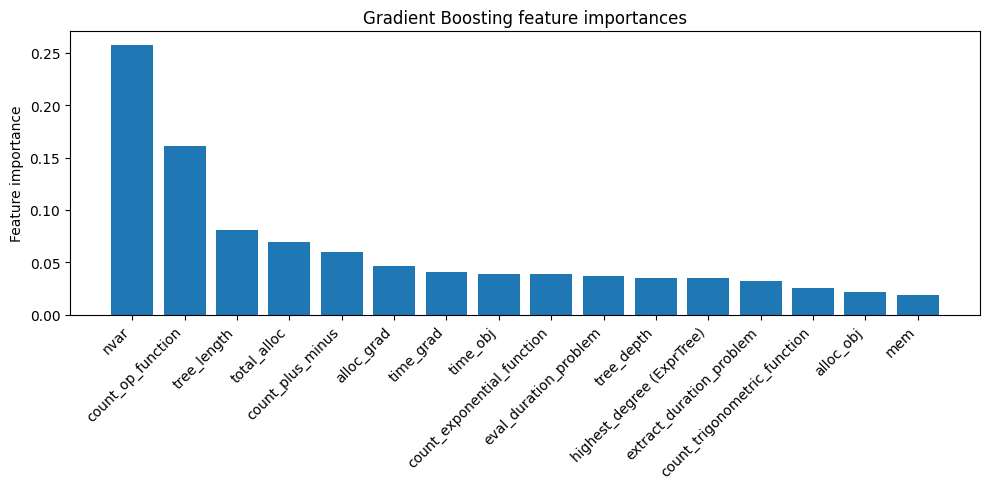

['./model_weights/best_gb_model_reg.pkl']

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os 

path = './model_weights/best_gb_model_reg.pkl'

if not os.path.isfile(path):
    best_model = random_search.best_estimator_
else:
    best_model = joblib.load('./model_weights/best_gb_model_reg.pkl')
best_model = random_search.best_estimator_
gb_importances = best_model.feature_importances_
indices_rf = np.argsort(gb_importances)[::-1]  

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_cols_reg)), gb_importances[indices_rf])
plt.xticks(range(len(feature_cols_reg)), [feature_cols_reg[i] for i in indices_rf], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Gradient Boosting feature importances")
plt.tight_layout()
plt.show()

joblib.dump(best_model, './model_weights/best_gb_model_reg.pkl')

In [46]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
pred = best_model.predict(X_test)
test_mse = mean_squared_error(y_test, pred)
test_r2  = r2_score(y_test, pred)
print(f"MSE={test_mse:.4f}  R²={test_r2:.4f}")

relative_error = np.abs(pred - y_test) / np.abs(y_test + 1e-8)

#exp((E[Y|xi])

thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
for i, col in enumerate(target_cols_reg):
    print(f"\n{col}:")
    print(f"Relative Error | Under Threshold | Percentage")
    for t in thresholds:
        rate = np.mean(relative_error[:, i] < t)
        print(f"  <{t:5.0%}:  {rate:.2%}")

MSE=2.2217  R²=0.4315

neval_obj:
Relative Error | Under Threshold | Percentage
  <   5%:  5.34%
  <  10%:  16.49%
  <  15%:  25.17%
  <  20%:  33.90%
  <  30%:  53.22%
  <  50%:  91.83%

neval_grad:
Relative Error | Under Threshold | Percentage
  <   5%:  6.17%
  <  10%:  12.93%
  <  15%:  23.15%
  <  20%:  30.56%
  <  30%:  41.56%
  <  50%:  81.59%

timed_bytes:
Relative Error | Under Threshold | Percentage
  <   5%:  72.88%
  <  10%:  89.88%
  <  15%:  96.17%
  <  20%:  99.17%
  <  30%:  99.98%
  <  50%:  100.00%


[]

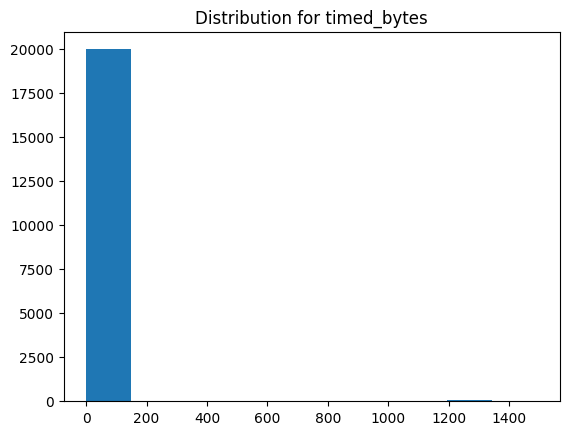

In [97]:
x = df["timed_bytes"] / 10**8
x = x[x < 2000]
plt.hist(x=x)
plt.title("Distribution for timed_bytes")
plt.plot()

### Using the predicted value of ["neval_obj", "neval_grad", "timed_bytes"] to predict time

In [15]:
X_train_time = best_model.predict(X_train)
X_test_time = best_model.predict(X_test)
y_train_time = np.log1p(train_df[target_col_model].to_numpy(dtype=float)).ravel()
y_test_time = np.log1p(test_df[target_col_model].to_numpy(dtype=float)).ravel()

In [18]:
time_predictor = xgb.XGBRegressor(objective='reg:squarederror')
time_predictor.fit(X_train_time, y_train_time)
time_predictor.score(X_test_time, y_test_time)

-0.5694766187014433

In [19]:
param_distributions = {
    'n_estimators': randint(50, 1500),
    'max_depth': randint(3, 15),  # XGBoost typically uses shallower trees
    'learning_rate': uniform(0.01, 0.29),  # 0.01 to 0.3
    'subsample': uniform(0.5, 0.5),  # 0.5 to 1.0
    'colsample_bytree': uniform(0.5, 0.5),  # 0.5 to 1.0
    'colsample_bylevel': uniform(0.5, 0.5),  # 0.5 to 1.0
    'colsample_bynode': uniform(0.5, 0.5),  # 0.5 to 1.0
    'min_child_weight': randint(1, 20),
    'gamma': uniform(0, 0.5),  # min loss reduction
    'reg_alpha': uniform(0, 10),  # L1 regularization
    'reg_lambda': uniform(0, 10),  # L2 regularization
}

rf = xgb.XGBRegressor(
    random_state=42, 
    n_jobs=-1,
    tree_method='hist'  # faster training
)

time_random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,  
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # Use all cores
    random_state=42,
    verbose=3,
    return_train_score=True,
    error_score='raise'
)

time_random_search.fit(X_train_time, y_train_time)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 2/5] END colsample_bylevel=0.6872700594236812, colsample_bynode=0.9753571532049581, colsample_bytree=0.8659969709057025, gamma=0.2993292420985183, learning_rate=0.055245405728306586, max_depth=5, min_child_weight=11, n_estimators=137, reg_alpha=3.337086111390218, reg_lambda=1.4286681792194078, subsample=0.8254442364744264;, score=(train=-0.339, test=-3.218) total time=   0.1s
[CV 3/5] END colsample_bylevel=0.6872700594236812, colsample_bynode=0.9753571532049581, colsample_bytree=0.8659969709057025, gamma=0.2993292420985183, learning_rate=0.055245405728306586, max_depth=5, min_child_weight=11, n_estimators=137, reg_alpha=3.337086111390218, reg_lambda=1.4286681792194078, subsample=0.8254442364744264;, score=(train=-0.402, test=-0.815) total time=   0.1s
[CV 5/5] END colsample_bylevel=0.6872700594236812, colsample_bynode=0.9753571532049581, colsample_bytree=0.8659969709057025, gamma=0.2993292420985183, learning_rate=0.05524

RandomizedSearchCV(cv=5, error_score='raise',
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          in...
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x1695e2290>,
                                        'reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x31b096ce0>,
                                        'reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x31b0961a0>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x31ae47220>},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_squared_error', verbose=3)

In [21]:
# time_best_model = joblib.load('./model_weights/best_gb_model_time.pkl')
time_best_model = time_random_search.best_estimator_
accuracy = time_best_model.score(X_test_time, y_test_time)
print(f"Time prediction accuracy based on predicted values={accuracy}")

joblib.dump(time_best_model, './model_weights/best_gb_model_time.pkl')

Time prediction accuracy based on predicted values=0.29321986494554664


['./model_weights/best_gb_model_time.pkl']

In [22]:
pred = time_best_model.predict(X_test_time)
test_mse = mean_squared_error(y_test_time, pred)
test_r2  = r2_score(y_test_time, pred)
print(f"MSE={test_mse:.4f}  R²={test_r2:.4f}")

relative_error = np.abs(pred - y_test_time) / np.abs(y_test_time + 1e-8)

#exp((E[Y|xi])

thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
for i, col in enumerate(target_col_model):
    print(f"\n{col}:")
    print(f"Relative Error | Under Threshold | Percentage")
    for t in thresholds:
        rate = np.mean(relative_error < t)
        print(f"  <{t:5.0%}:  {rate:.2%}")

MSE=2.8018  R²=0.2932

stats_elapsed_time:
Relative Error | Under Threshold | Percentage
  <   5%:  2.12%
  <  10%:  5.98%
  <  15%:  9.05%
  <  20%:  10.90%
  <  30%:  15.93%
  <  50%:  22.63%


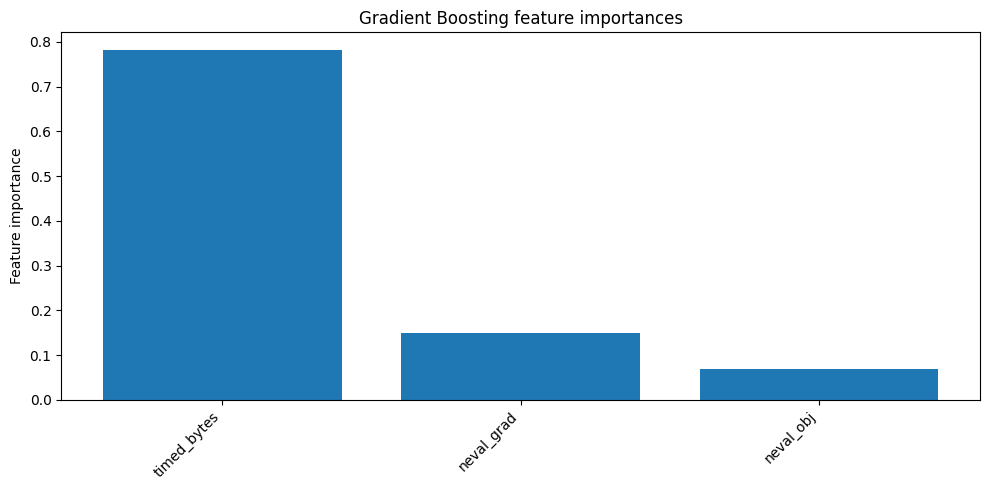

In [25]:
best_model_time = time_best_model
gb_importances = best_model_time.feature_importances_
indices_gb = np.argsort(gb_importances)[::-1]  

plt.figure(figsize=(10, 5))
plt.bar(range(len(target_cols_reg)), gb_importances[indices_gb])
plt.xticks(range(len(target_cols_reg)), [target_cols_reg[i] for i in indices_gb], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Gradient Boosting feature importances")
plt.tight_layout()
plt.show()

### Using the actual value of ["neval_obj", "neval_grad", "timed_bytes"] to predict time

In [27]:
X_train_time = train_df[target_cols_reg]
X_test_time = test_df[target_cols_reg]
y_train_time = np.log1p(train_df[target_col_model].to_numpy(dtype=float)).ravel()
y_test_time = np.log1p(test_df[target_col_model].to_numpy(dtype=float)).ravel()

In [28]:
time_predictor =  xgb.XGBRegressor(objective='reg:squarederror')
time_predictor.fit(X_train_time, y_train_time)
time_predictor.score(X_test_time, y_test_time)

0.45553338207021565

In [55]:
param_distributions = {
    'n_estimators': randint(50, 1500),
    'max_depth': randint(3, 15),
    'learning_rate': uniform(0.01, 0.29),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'colsample_bylevel': uniform(0.5, 0.5),
    'colsample_bynode': uniform(0.5, 0.5),
    'min_child_weight': randint(1, 20),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 10),
    'reg_lambda': uniform(0, 10),
}

rf = xgb.XGBRegressor(
    random_state=42, 
    n_jobs=-1,
    tree_method='hist'
)

time_random_search_raw = RandomizedSearchCV(
    rf,
    param_distributions=param_distributions,
    n_iter=500,
    cv=10,  
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=3,
    return_train_score=True
)

time_random_search_raw.fit(X_train_time, y_train_time)

Fitting 10 folds for each of 500 candidates, totalling 5000 fits
[CV 1/10] END colsample_bylevel=0.6872700594236812, colsample_bynode=0.9753571532049581, colsample_bytree=0.8659969709057025, gamma=0.2993292420985183, learning_rate=0.055245405728306586, max_depth=5, min_child_weight=11, n_estimators=137, reg_alpha=3.337086111390218, reg_lambda=1.4286681792194078, subsample=0.8254442364744264;, score=(train=-0.472, test=-2.070) total time=   0.1s
[CV 2/10] END colsample_bylevel=0.6872700594236812, colsample_bynode=0.9753571532049581, colsample_bytree=0.8659969709057025, gamma=0.2993292420985183, learning_rate=0.055245405728306586, max_depth=5, min_child_weight=11, n_estimators=137, reg_alpha=3.337086111390218, reg_lambda=1.4286681792194078, subsample=0.8254442364744264;, score=(train=-0.468, test=-0.504) total time=   0.1s
[CV 5/10] END colsample_bylevel=0.6872700594236812, colsample_bynode=0.9753571532049581, colsample_bytree=0.8659969709057025, gamma=0.2993292420985183, learning_rate=0

RandomizedSearchCV(cv=10,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constrain...
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x31c9f51e0>,
                                        'reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x31cca73d0>,
                                        'reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x31cca66b0>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x31cca6ce0>},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_squared_error', verbose=3)

In [56]:
time_best_model_raw = time_random_search_raw.best_estimator_
# time_best_model_raw = joblib.load('./model_weights/best_gb_model_time_raw.pkl')
accuracy = time_best_model_raw.score(X_test_time, y_test_time)
print(f"Time prediction accuracy based on predicted values={accuracy}")

joblib.dump(time_best_model_raw, './model_weights/best_gb_model_time_raw.pkl')

Time prediction accuracy based on predicted values=0.708182084172001


['./model_weights/best_gb_model_time_raw.pkl']

In [57]:
pred = time_best_model_raw.predict(X_test_time)
test_mse = mean_squared_error(y_test_time, pred)
test_r2  = r2_score(y_test_time, pred)
print(f"MSE={test_mse:.4f}  R²={test_r2:.4f}")

relative_error = np.abs(pred - y_test_time) / np.abs(y_test_time + 1e-8)

#exp((E[Y|xi])

thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
for i, col in enumerate(target_col_model):
    print(f"\n{col}:")
    print(f"Relative Error | Under Threshold | Percentage")
    for t in thresholds:
        rate = np.mean(relative_error < t)
        print(f"  <{t:5.0%}:  {rate:.2%}")

MSE=1.1568  R²=0.7082

stats_elapsed_time:
Relative Error | Under Threshold | Percentage
  <   5%:  7.24%
  <  10%:  13.46%
  <  15%:  15.37%
  <  20%:  16.95%
  <  30%:  24.78%
  <  50%:  33.95%


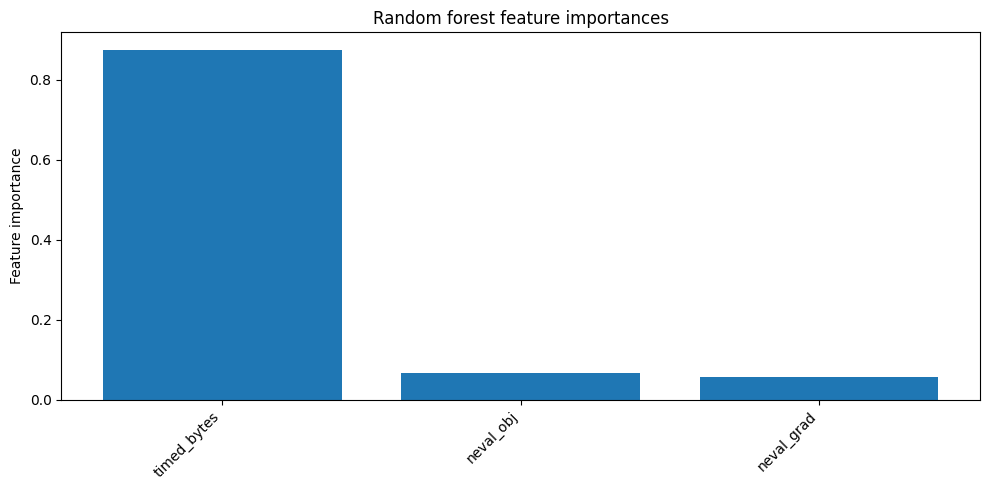

In [58]:
best_model_time_raw = time_best_model_raw
gb_importances = best_model_time_raw.feature_importances_
indices_gb = np.argsort(gb_importances)[::-1]  

plt.figure(figsize=(10, 5))
plt.bar(range(len(target_cols_reg)), gb_importances[indices_gb])
plt.xticks(range(len(target_cols_reg)), [target_cols_reg[i] for i in indices_gb], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Random forest feature importances")
plt.tight_layout()
plt.show()

### Now let's use stats_ellapsed_time to predict the corresponding best mem value

In [59]:
group_cols = ["problem", "name", "nvar"]
best_idx = df.groupby(group_cols)["stats_elapsed_time"].idxmin()
best_mem_map = df.loc[best_idx].set_index(group_cols)["mem"]
df["best_observed_mem"] = df.set_index(group_cols).index.map(best_mem_map)

In [60]:
test_df

,tree_depth,neval_grad,mem,problem,neval_obj,time_grad,eval_duration_problem,count_plus_minus,timed_bytes,nvar,highest_degree (ExprTree),count_op_function,name,count_trigonometric_function,stats_elapsed_time,count_exponential_function,time_obj,tree_length,extract_duration_problem,total_alloc,alloc_grad,alloc_obj,index,nvmops,objective,eval_duration_solver,extract_duration_solver,dual_feas,status,timed_time,timed_gctime,nlp_warmup_time,iter,source_solver,timestamp_solver,error_solver,vector_type,nln_nnzj,adbackend_hessian_backend_type,minimize,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,matrix_free,nlin,is_constant (ExprTree),nnzj,alloc_hprod,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,islp,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,mem_count
0,8.0,8.0,1,OptimizationProb...,56.0,1.029701,3.275820,400.0,20176.0,100,2.0,20600.0,arglinb,0.0,0.000229,0.0,0.288629,40200.0,6.859471,98.224056,52547568.0,45676488.0,4502,2.0,2.481297e+01,0.290308,0.011412,0.055305,first_order,0.000254,0.000000,0.309318,2.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5050.0,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100
1,8.0,4.0,2,OptimizationProb...,28.0,1.029701,3.275820,400.0,23720.0,100,2.0,20600.0,arglinb,0.0,0.000294,0.0,0.288629,40200.0,6.859471,98.224056,52547568.0,45676488.0,4503,2.0,2.481297e+01,0.290308,0.011532,0.055305,first_order,0.000376,0.000000,0.309318,2.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5050.0,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100
2,8.0,4.0,3,OptimizationProb...,28.0,1.029701,3.275820,400.0,27192.0,100,2.0,20600.0,arglinb,0.0,0.000294,0.0,0.288629,40200.0,6.859471,98.224056,52547568.0,45676488.0,4504,2.0,2.481297e+01,0.290308,0.011493,0.055305,first_order,0.000387,0.000000,0.309318,2.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0

In [61]:
X_all_time = all_df[target_cols_reg]
y_pred = best_model_time_raw.predict(X_all_time)
y_pred_df = pd.DataFrame(y_pred, columns=["predicted_time"])
y_pred_df
all_df_new = all_df.join(y_pred_df, how="inner").reset_index(drop=True)
all_df_new


,tree_depth,neval_grad,mem,problem,neval_obj,time_grad,eval_duration_problem,count_plus_minus,timed_bytes,nvar,highest_degree (ExprTree),count_op_function,name,count_trigonometric_function,stats_elapsed_time,count_exponential_function,time_obj,tree_length,extract_duration_problem,total_alloc,alloc_grad,alloc_obj,index,nvmops,objective,eval_duration_solver,extract_duration_solver,dual_feas,status,timed_time,timed_gctime,nlp_warmup_time,iter,source_solver,timestamp_solver,error_solver,vector_type,nln_nnzj,adbackend_hessian_backend_type,minimize,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,matrix_free,nlin,is_constant (ExprTree),nnzj,alloc_hprod,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,islp,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,mem_count,predicted_time
0,9.0,4.0,1,OptimizationProb...,4.0,0.464686,1.980544,305.0,18576.0,100,2.0,509.0,arglina,0.0,0.000135,0.0,0.376715,10404.0,4.309682,77.126264,42611104.0,34515160.0,15689,1.0,5.000000e+01,0.319062,0.011306,7.841650e-15,first_order,0.000164,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5050.0,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100,-0.304500
1,9.0,2.0,2,OptimizationProb...,2.0,0.464686,1.980544,305.0,22120.0,100,2.0,509.0,arglina,0.0,0.000151,0.0,0.376715,10404.0,4.309682,77.126264,42611104.0,34515160.0,15690,1.0,5.000000e+01,0.319062,0.011309,7.841650e-15,first_order,0.000199,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5050.0,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100,-0.281725
2,9.0,2.0,3,OptimizationProb...,2.0,0.464686,1.980544,305.0,25592.0,100,2.0,509.0,arglina,0.0,0.000140,0.0,0.376715,10404.0,4.309682,77.126264,42611104.0,34515160.0,15691,1.0,5.000000e+01,0.319062,0.011275,7.841650e-15,first_order,0.000182,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt

In [62]:
group_cols = ["problem", "name", "nvar"]
best_idx = df.groupby(group_cols)["stats_elapsed_time"].idxmin()
best_mem_map = df.loc[best_idx].set_index(group_cols)["mem"]
df["best_observed_mem"] = df.set_index(group_cols).index.map(best_mem_map)

In [63]:
group_cols = ["problem", "name", "nvar"]
best_idx = all_df_new.groupby(group_cols)["predicted_time"].idxmin()
best_mem_map = all_df_new.loc[best_idx].set_index(group_cols)["mem"]
all_df_new["best_predicted_mem"] = all_df_new.set_index(group_cols).index.map(best_mem_map)
all_df_new["best_predicted_mem"].describe()

count    20100.000000
mean         9.746269
std         16.030852
min          1.000000
25%          2.000000
50%          4.000000
75%          7.000000
max         92.000000
Name: best_predicted_mem, dtype: float64

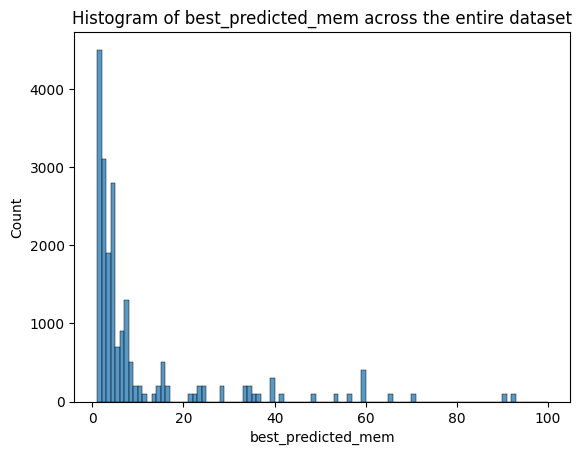

In [79]:
# %pip install seaborn
import seaborn as sns
x = all_df_new["best_predicted_mem"]
x.describe()
sns.histplot(x=x,bins=[i+1 for i in range(100)])
plt.title("Histogram of best_predicted_mem across the entire dataset")
plt.show()

In [67]:
all_df_new["best_observed_mem"] = df["best_observed_mem"]
all_df_new

,tree_depth,neval_grad,mem,problem,neval_obj,time_grad,eval_duration_problem,count_plus_minus,timed_bytes,nvar,highest_degree (ExprTree),count_op_function,name,count_trigonometric_function,stats_elapsed_time,count_exponential_function,time_obj,tree_length,extract_duration_problem,total_alloc,alloc_grad,alloc_obj,index,nvmops,objective,eval_duration_solver,extract_duration_solver,dual_feas,status,timed_time,timed_gctime,nlp_warmup_time,iter,source_solver,timestamp_solver,error_solver,vector_type,nln_nnzj,adbackend_hessian_backend_type,minimize,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,matrix_free,nlin,is_constant (ExprTree),nnzj,alloc_hprod,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,islp,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,mem_count,predicted_time,best_predicted_mem,best_observed_mem
0,9.0,4.0,1,OptimizationProb...,4.0,0.464686,1.980544,305.0,18576.0,100,2.0,509.0,arglina,0.0,0.000135,0.0,0.376715,10404.0,4.309682,77.126264,42611104.0,34515160.0,15689,1.0,5.000000e+01,0.319062,0.011306,7.841650e-15,first_order,0.000164,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5050.0,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100,-0.304500,1,1
1,9.0,2.0,2,OptimizationProb...,2.0,0.464686,1.980544,305.0,22120.0,100,2.0,509.0,arglina,0.0,0.000151,0.0,0.376715,10404.0,4.309682,77.126264,42611104.0,34515160.0,15690,1.0,5.000000e+01,0.319062,0.011309,7.841650e-15,first_order,0.000199,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5050.0,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100,-0.281725,1,1
2,9.0,2.0,3,OptimizationProb...,2.0,0.464686,1.980544,305.0,25592.0,100,2.0,509.0,arglina,0.0,0.000140,0.0,0.376715,10404.0,4.309682,77.126264,42611104.0,34515160.0,15691,1.0,5.000000e+01,0.319062,0.011275,7.841650e-15,first_order,0.000182,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationPro

In [68]:
differences = np.mean(abs(all_df_new["best_observed_mem"] - all_df_new["best_predicted_mem"]))
print(f"Global mem prediction difference={differences}")

Global mem prediction difference=33.38308457711443


In [98]:
# Absolute time difference (regret)
time_differences = all_df_new["stats_elapsed_time"] - all_df_new["predicted_time"]
mean_absolute_regret = np.mean(time_differences)
print(f"Mean absolute time regret: {mean_absolute_regret}")
time_differences

Mean absolute time regret: 133.58946835724385


0        0.304635
1        0.281876
2        0.281866
3        0.281876
4        0.281864
           ...   
20095   -6.092930
20096   -5.919832
20097   -5.919947
20098   -5.957760
20099   -6.237282
Length: 20100, dtype: float64

True distribution of best mem:
best_observed_mem
1      0.119403
2      0.034826
3      0.054726
4      0.069652
5      0.029851
         ...   
96     0.019900
97     0.024876
98     0.004975
99     0.039801
100    0.034826
Name: proportion, Length: 61, dtype: float64


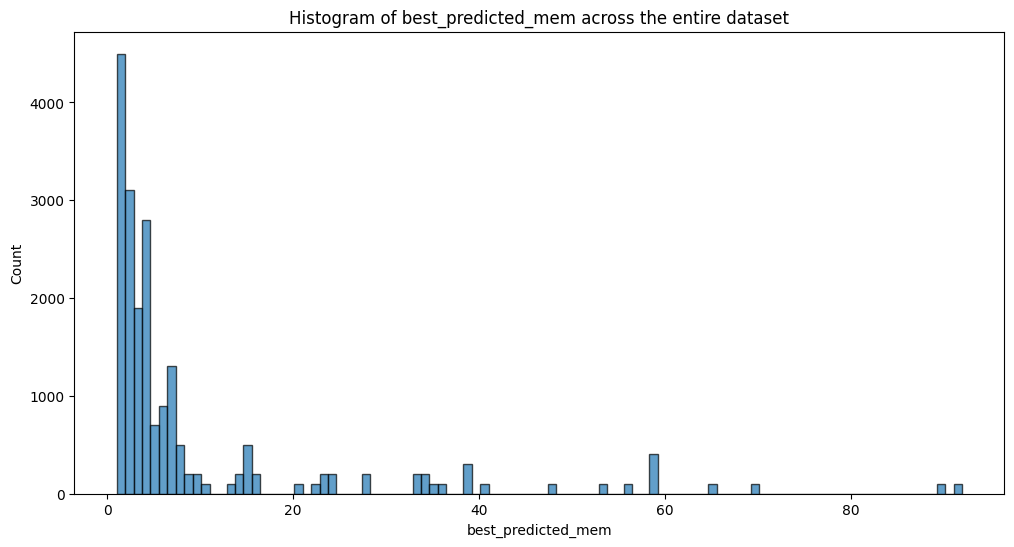

In [70]:
# Distribution of actual best mems
print("True distribution of best mem:")
print(all_df_new['best_observed_mem'].value_counts(normalize=True).sort_index())

# Predicted distribution (should match the observed pattern above)
plt.figure(figsize=(12, 6))
plt.hist(all_df_new['best_predicted_mem'], bins=100, edgecolor='black', alpha=0.7)
plt.title('Histogram of best_predicted_mem across the entire dataset')
plt.xlabel('best_predicted_mem')
plt.ylabel('Count')
plt.show()

### Mem evaluation metrics

In [71]:
# How far off is the predicted mem from actual (in mem units)
mem_absolute_error = abs(all_df_new['best_predicted_mem'] - all_df_new['best_observed_mem'])
mame = np.mean(mem_absolute_error)
print(f"Mean Absolute Mem Error: {mame:.2f}")
print(f"Median Absolute Mem Error: {np.median(mem_absolute_error):.2f}")

Mean Absolute Mem Error: 33.38
Median Absolute Mem Error: 16.00


In [72]:
# How close are the predictions? 1.0 = perfect, 0.0 = very far
mem_match_ratio = np.minimum(all_df_new['best_predicted_mem'], 
                              all_df_new['best_observed_mem']) / \
                  np.maximum(all_df_new['best_predicted_mem'], 
                              all_df_new['best_observed_mem'])

mean_match_ratio = np.mean(mem_match_ratio)
print(f"Mean Mem Match Ratio: {mean_match_ratio:.3f}")
# 1.0 = perfect match
# 0.5 = off by 2x (e.g., pred=50, actual=100)
# 0.1 = off by 10x (e.g., pred=10, actual=100)

Mean Mem Match Ratio: 0.296
